In [11]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

In [ ]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep

import numpy as np
import matplotlib.pyplot as plt

apply(context="paper", col="single")


save_path = "/Users/niaggar/Documents/Thesis/tests"
folder = "test_slices_grid"

In [ ]:


# Constantes del estudio (host acuoso, linea de Iwai)
N_MEDIUM = 1.33
WAVELENGTH = 0.514
K_MEDIUM = 2.0 * np.pi * N_MEDIUM / WAVELENGTH   # ~16.26 um^-1

# Radio representativo para el desglose de canales (Fig. C)
RADIUS_CHANNELS = 0.175

# ---------------------------------------------------------------------------
# Carga y perfiles co-pol por radio
# ---------------------------------------------------------------------------
sweep_data = load_sweep(folder)
run_names = sorted(sweep_data.keys())

profiles = {}
for name in run_names:
    loader = sweep_data[name]
    p = loader.params
    radius = p.layers[0].medium.radius
    lstar = p.extra["transport_mean_free_path"]
    prof = cbs_profiles(loader.processed_cbs("farfield_cbs"), basis=circular, time_index=0, reduce=keep)

    primera_lista = prof.enhancement["co"][:, 0]
    segunda_lista = prof.enhancement["co"][:, 1]
    print(primera_lista.size)
    print(segunda_lista.size)

    profiles[radius] = {
        "prof": prof,
        "lstar": lstar,
        "theta_coh": 1.0 / (K_MEDIUM * lstar),   # rad, calculo correcto
    }

radii = sorted(profiles)


500
500


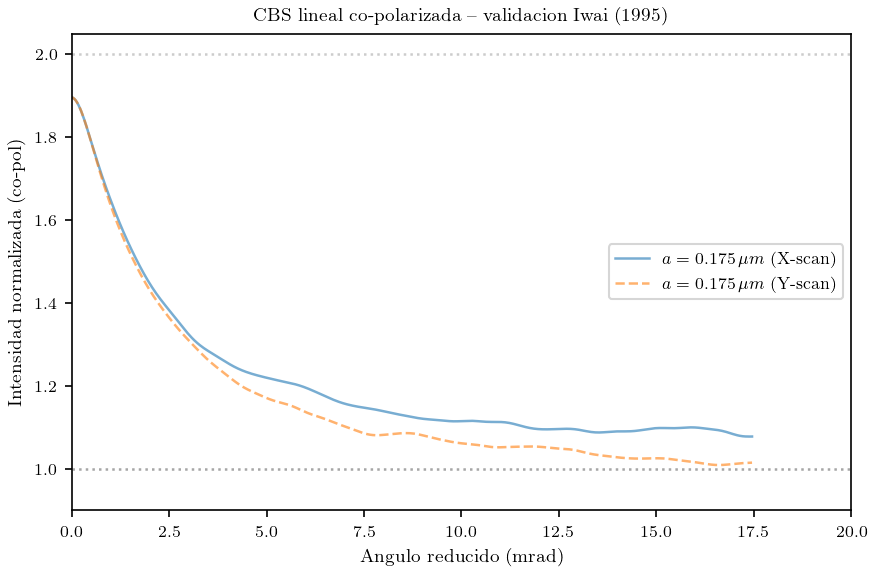

In [27]:

# ===========================================================================
# Figura A: overlay co-polarizado (analogo Iwai Fig. 2a)
# ===========================================================================
fig, ax = plt.subplots(figsize=(6, 4))
for radius in radii:
    d = profiles[radius]
    x_chanel = d["prof"].enhancement["co"][:, 0]
    y_chanel = d["prof"].enhancement["co"][:, 1]
    ax.plot(d["prof"].theta * 1e3, x_chanel, label=fr"$a={radius:.3f}\,\mu m$ (X-scan)", ls="-", alpha=0.6)
    ax.plot(d["prof"].theta * 1e3, y_chanel, label=fr"$a={radius:.3f}\,\mu m$ (Y-scan)", ls="--", alpha=0.6)
ax.axhline(1.0, color="gray", ls=":", alpha=0.7)
ax.axhline(2.0, color="gray", ls=":", alpha=0.4)
ax.set_xlim(0, 20)                                # rango de Iwai (mrad)
ax.set_ylim(0.9, 2.05)
ax.set_xlabel("Angulo reducido (mrad)")
ax.set_ylabel("Intensidad normalizada (co-pol)")
ax.set_title("CBS lineal co-polarizada -- validacion Iwai (1995)")
ax.legend()
fig.tight_layout()

# # ===========================================================================
# # Figura B: colapso en variable reducida q = k l* theta
# # ===========================================================================
# fig, ax = plt.subplots(figsize=(6, 4))
# for radius in radii:
#     d = profiles[radius]
#     q = K_MEDIUM * d["lstar"] * d["prof"].theta
#     ax.plot(q, d["prof"].enhancement["co"], label=fr"$a={radius:.3f}\,\mu m$")
# ax.axhline(1.0, color="gray", ls=":", alpha=0.7)
# ax.set_xlim(0, 10)
# ax.set_ylim(0.9, 2.05)
# ax.set_xlabel(r"$q = k\,\ell^{*}\,\theta$")
# ax.set_ylabel("Intensidad normalizada (co-pol)")
# ax.set_title("Colapso del cono CBS en variable reducida")
# ax.legend()
# fig.tight_layout()

# # ===========================================================================
# # Figura C: canales co / cross / total para un radio
# # ===========================================================================
# d = profiles[RADIUS_CHANNELS]
# theta_mrad = d["prof"].theta * 1e3

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(theta_mrad, d["prof"].enhancement["total"], label="total")
# ax.plot(theta_mrad, d["prof"].enhancement["co"], label=r"co-pol ($\parallel$)")
# ax.plot(theta_mrad, d["prof"].enhancement["cross"], label=r"cross-pol ($\perp$)")
# ax.axhline(1.0, color="gray", ls=":", alpha=0.7)
# ax.axvline(d["theta_coh"] * 1e3, color="red", ls="--", alpha=0.6,
#            label=r"$1/(k\,\ell^{*})$")
# ax.set_xlim(0, 20)
# ax.set_xlabel("Angulo reducido (mrad)")
# ax.set_ylabel("Factor de realce")
# ax.set_title(fr"Canales CBS -- $a={RADIUS_CHANNELS:.3f}\,\mu m$")
# ax.legend()
# fig.tight_layout()